In [2]:
import torch 
def compute_z(a,b,c):
    r1=torch.sub(a,b)
    r2=torch.multi(r1,2)
    z=torch.add(r2,c)
    return z

In [3]:
import torch.nn as nn
torch.manual_seed(1)
w=torch.empty(2,3)
nn.init.xavier_normal_(w)
print(w)

tensor([[ 0.4183,  0.1688,  0.0390],
        [ 0.3930, -0.2858, -0.1051]])


In [4]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.w1=torch.empty(2,3,requires_grad=True)
        nn.init.xavier_normal_(self.w1)
        self.w2=torch.empty(1,2,requires_grad=True)
        nn.init.xavier._normal_(self.w2)


In [5]:
model=nn.Sequential(nn.Linear(4,16),nn.ReLU(),nn.Linear(16,32),nn.ReLU())
model

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
)

In [6]:
nn.init.xavier_uniform_(model[0].weight)
l1_weight=0.01
l1_penalty=l1_weight*model[2].weight.abs().sum()

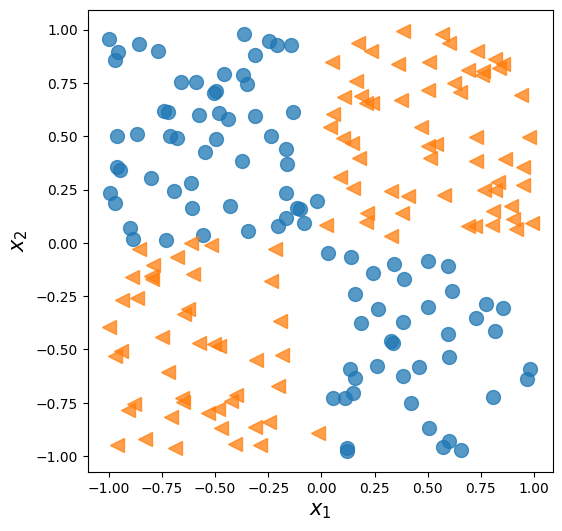

In [7]:
import matplotlib.pyplot as plt
import numpy as np
torch.manual_seed(1)
np.random.seed(1)
x=np.random.uniform(low=-1,high=1,size=(200,2))
y=np.ones(len(x))
y[x[:,0]*x[:,1]<0]=0
n_train=100
x_train=torch.tensor(x[:n_train,:],dtype=torch.float32)
y_train = torch.tensor(y[:n_train], dtype=torch.float32)
x_valid = torch.tensor(x[n_train:, :], dtype=torch.float32)
y_valid = torch.tensor(y[n_train:], dtype=torch.float32)
fig = plt.figure(figsize=(6, 6))
plt.plot(x[y==0, 0], x[y==0, 1], 'o', alpha=0.75, markersize=10)
plt.plot(x[y==1, 0], x[y==1, 1], '<', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)
plt.show()

In [8]:
model=nn.Sequential(nn.Linear(2,1),nn.Sigmoid())
model

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

In [9]:
loss_fn=nn.BCELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.001)
from torch.utils.data import DataLoader,TensorDataset

train_ds=TensorDataset(x_train,y_train)
batch_size=2
torch.manual_seed(1)
train_dl=DataLoader(train_ds,batch_size,shuffle=True)
torch.manual_seed(1)
num_epochs=200

def train(model,num_epochs,train_dl,x_valid,y_valid):
    loss_hist_train=[0]*num_epochs
    accuracy_hist_train=[0]*num_epochs
    loss_hist_valid=[0]*num_epochs
    accuracy_hist_valid=[0]*num_epochs
    for epoch in range(num_epochs):
        for x_batch,y_batch in train_dl:
            pred=model(x_batch)[:,0]
            loss=loss_fn(pred,y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        loss_hist_train[epoch]+=loss.item()
        is_correct=((pred>=0.5).float()==y_batch).float()
        accuracy_hist_train[epoch]+=is_correct.mean()
        pred=model(x_valid)[:,0]
        loss=loss_fn(pred,y_valid)
        loss_hist_valid[epoch]=loss.item()
        is_correct=((pred>=0.5).float()==y_valid).float()
        accuracy_hist_valid[epoch]+=is_correct.mean()
    return loss_hist_train, loss_hist_valid,accuracy_hist_train, accuracy_hist_valid    

In [10]:
history = train(model, num_epochs, train_dl, x_valid, y_valid)

/media/WORK/CODING/rashcka_ml/venv/lib/python3.12/site-packages/torch/autograd/graph.py:824: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [11]:
model=nn.Sequential(nn.Linear(2,4),nn.ReLU(),nn.Linear(4,4),nn.ReLU(),nn.Linear(4,1),nn.Sigmoid())
loss_fn=nn.BCELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.015)
model

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
  (5): Sigmoid()
)

In [12]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        l1=nn.Linear(2,4)
        a1=nn.ReLU()
        l2=nn.Linear(4,4)
        a2=nn.ReLU()
        l3=nn.Linear(4,1)
        a3=nn.Sigmoid()
        l=[l1,a1,l2,a2,l3,a3]
        self.module_list=nn.ModuleList(l)

    def forward(self,x):
        for f in nn.module_list:
            x=f(x)
        return x        
    
    def predict(self,x):
        x=torch.tensor(x,dtype=torch.float32)
        pred=self.forward(x)[:,0]
        return (pred>=0.5).float()
    

In [13]:
model=MyModule()
model

MyModule(
  (module_list): ModuleList(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [14]:
class NoisyLayer(nn.Module):
    def __init__(self,input_size,output_size,noise_stddev=0.1):
        super().__init__()
        w=torch.Tensor(input_size,output_size)
        self.w=nn.Parameter(w)
        nn.init.xavier_uniform_(self.w)
        b=torch.Tensor(output_size).fill_(0)
        self.b=nn.Parameter(b)
        self.noise_stddev=noise_stddev

    def forward(self,x,training=False):
        if training:
            noise=torch.normal(0.0,self.noise_stddev,x.shape)
            x_new=torch.add(x,noise)
        else:
            x_new=x
        return torch.add(torch.mm(x_new,self.w),self.b)        

In [15]:
class MyNoisyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1=NoisyLayer(2,4,0.07)
        self.a1=nn.ReLU()
        self.l2=nn.Linear(4,4)
        self.a2=nn.ReLU()
        self.l3=nn.Linear(4,1)
        self.a3=nn.Sigmoid()

    def forward(self,x,training=False):
        x=self.l1(x,training)
        x=self.a1(x)
        x=self.l2(x)
        x=self.a2(x)
        x=self.l3(x)
        x=self.a3(x)
        return x
    
    def predict(self,x):
        x=torch.tensor(x,dtype=torch.float32)
        pred=self.forward(x)[:,0]
        return (pred>-0.5).float()
    
torch.manual_seed(1)
model=MyNoisyModule()
model




MyNoisyModule(
  (l1): NoisyLayer()
  (a1): ReLU()
  (l2): Linear(in_features=4, out_features=4, bias=True)
  (a2): ReLU()
  (l3): Linear(in_features=4, out_features=1, bias=True)
  (a3): Sigmoid()
)

In [16]:
loss_fn=nn.BCELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.015)
torch.manual_seed(1)
loss_hist_train=[0]*num_epochs
accuracy_hist_train=[0]*num_epochs
loss_hist_valid=[0]*num_epochs
accuracy_hist_valid=[0]*num_epochs

for epoch in range(num_epochs):
    for x_batch,y_batch in train_dl:
        pred = model(x_batch, True)[:, 0]
        loss=loss_fn(pred,y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist_train[epoch]+=loss.item()
        is_correct = ((pred>=0.5).float() == y_batch).float()
        accuracy_hist_train[epoch]+=is_correct.mean()
    loss_hist_train[epoch]/=n_train/batch_size
    accuracy_hist_train[epoch]/=n_train/batch_size
    pred = model(x_valid)[:, 0]    
    loss=loss_fn(pred,y_valid)
    loss_hist_valid[epoch]=loss.item()
    is_correct=((pred>=0.5).float()==y_valid).float()
    accuracy_hist_valid[epoch] += is_correct.mean()

In [17]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names=['MPG','Cylinders','Displacement','Horsepower','Weight','Acceleration','Model Year','Origin']
df=pd.read_csv(url,names=column_names,na_values="?",comment='\t',sep=" ",skipinitialspace=True)
df=df.dropna()
df=df.reset_index(drop=True)

import sklearn
from sklearn.model_selection import train_test_split

df_train,df_test=train_test_split(df,train_size=0.8,random_state=1)

train_stats=df_train.describe().transpose()
numeric_column_names=['Cylinders','Displacement','Horsepower','Weight','Acceleration']
df_train_nom,df_test_nom=df_train.copy(),df_test.copy()
for col_name in numeric_column_names:
    mean=train_stats.loc[col_name,'mean']
    std=train_stats.loc[col_name,'std']
    df_train_nom.loc[:, col_name] = (df_train_nom.loc[:, col_name] - mean)/std
    df_test_nom.loc[:, col_name] =(df_test_nom.loc[:, col_name] - mean)/std

df_train_nom.tail()
   

/tmp/ipykernel_243421/1841290755.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.8243028   0.3511267  -0.8243028  -0.8243028  -0.8243028   1.52655621
  0.3511267  -0.8243028  -0.8243028  -0.8243028   0.3511267  -0.8243028
  0.3511267   1.52655621  1.52655621  1.52655621  0.3511267   1.52655621
 -0.8243028   0.3511267   1.52655621 -0.8243028  -0.8243028   0.3511267
 -0.8243028  -0.8243028  -0.8243028   0.3511267  -0.8243028   1.52655621
  0.3511267  -0.8243028   0.3511267  -0.8243028  -0.8243028   1.52655621
 -0.8243028   1.52655621  1.52655621 -0.8243028  -0.8243028  -0.8243028
 -0.8243028   0.3511267  -0.8243028   1.52655621 -0.8243028  -0.8243028
  1.52655621 -0.8243028  -0.8243028  -0.8243028   1.52655621  1.52655621
  0.3511267   0.3511267   1.52655621 -0.8243028  -0.8243028   1.52655621
  1.52655621 -0.8243028  -0.8243028   0.3511267   1.52655621 -0.8243028
  0.3511267  -0.8243028   1.52655621  1.5265

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
203,28.0,-0.824303,-0.901020,-0.736562,-0.950031,0.255202,76,3
255,19.4,0.351127,0.413800,-0.340982,0.293190,0.548737,78,1
72,13.0,1.526556,1.144256,0.713897,1.339617,-0.625403,72,1
235,30.5,-0.824303,-0.891280,-1.053025,-1.072585,0.475353,77,1
37,14.0,1.526556,1.563051,1.636916,1.470420,-1.359240,71,1


In [18]:
df.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [19]:
from torch.nn.functional import one_hot
boundaries = torch.tensor([73, 76, 79])
v_train = torch.tensor(df_train_nom['Model Year'].values)
df_train_nom['Model Year Bucketed'] = torch.bucketize(v_train, boundaries, right=True).numpy()

v_test = torch.tensor(df_test_nom['Model Year'].values)
df_test_nom['Model Year Bucketed'] = torch.bucketize(v_test, boundaries, right=True).numpy()

if 'Model Year Bucketed' not in numeric_column_names:
    numeric_column_names.append('Model Year Bucketed')

# --- 2. One-hot encode Origin ---
origin_encoded_train = one_hot(torch.from_numpy(df_train_nom['Origin'].values - 1))
origin_encoded_test  = one_hot(torch.from_numpy(df_test_nom['Origin'].values - 1))

# --- 3. Numeric features ---
x_train_numeric = torch.tensor(df_train_nom[numeric_column_names].values)
x_train = torch.cat([x_train_numeric, origin_encoded_train], 1).float()

x_test_numeric = torch.tensor(df_test_nom[numeric_column_names].values)
x_test = torch.cat([x_test_numeric, origin_encoded_test], 1).float()

# --- 4. Targets ---
y_train = torch.tensor(df_train_nom['MPG'].values).float()
y_test  = torch.tensor(df_test_nom['MPG'].values).float()

# --- 5. Sanity check shapes ---
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

torch.Size([313, 9]) torch.Size([79, 9])
torch.Size([313]) torch.Size([79])


In [20]:
train_ds=TensorDataset(x_train,y_train)
batch_size=8
torch.manual_seed(1)
train_d1=DataLoader(train_ds,batch_size,shuffle=True)
hidden_units=[8,4]
input_size=x_train.shape[1]
all_layers=[]
for hidden_unit in hidden_units:
    layer=nn.Linear(input_size,hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size=hidden_unit
all_layers.append(nn.Linear(hidden_units[-1],1))
model=nn.Sequential(*all_layers)
model    

Sequential(
  (0): Linear(in_features=9, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
)

In [21]:
loss_fn=nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.001)
torch.manual_seed(1)
num_epochs=200
log_epochs=20

for epoch in range(num_epochs):
    loss_hist_train=0
    for x_batch,y_batch in train_d1:
        pred=model(x_batch)[:,0]
        loss=loss_fn(pred,y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist_train+=loss.item()
    if epoch%log_epochs==0:
        print(f'Epoch {epoch}Loss ' f'{loss_hist_train/len(train_dl):.4f}')   

Epoch 0Loss 421.0493
Epoch 20Loss 6.7828
Epoch 40Loss 6.1726
Epoch 60Loss 5.9454
Epoch 80Loss 5.6465
Epoch 100Loss 5.5877
Epoch 120Loss 5.2653
Epoch 140Loss 5.4912
Epoch 160Loss 5.8696
Epoch 180Loss 5.1828


In [22]:
with torch.no_grad():
 pred = model(x_test.float())[:, 0]
 loss = loss_fn(pred, y_test)
 print(f'Test MSE: {loss.item():.4f}')
 print(f'Test MAE: {nn.L1Loss()(pred, y_test).item():.4f}')

Test MSE: 9.0025
Test MAE: 1.9112


In [23]:
import torchvision
from torchvision import transforms
image_path='./'
transform=transforms.Compose([transforms.ToTensor()])

mnist_train_dataset=torchvision.datasets.MNIST(root=image_path,train=True,transform=transform,download=False)
mnist_test_dataset = torchvision.datasets.MNIST(root=image_path, train=False,transform=transform, download=False)
batch_size=64;
torch.manual_seed(1);
train_dl=DataLoader(mnist_train_dataset,batch_size,shuffle=True);

In [24]:
hidden_units=[32,16];
image_size=mnist_train_dataset[0][0].shape;
input_size=image_size[0]*image_size[1]*image_size[2];
all_layers=[nn.Flatten()]
for hidden_unit in hidden_units:
    layer=nn.Linear(input_size,hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size=hidden_unit
all_layers.append(nn.Linear(hidden_units[-1],10))
model=nn.Sequential(*all_layers)
model    

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=32, bias=True)
  (2): ReLU()
  (3): Linear(in_features=32, out_features=16, bias=True)
  (4): ReLU()
  (5): Linear(in_features=16, out_features=10, bias=True)
)

In [29]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
torch.manual_seed(1)
num_epochs=20
for epoch in range(num_epochs):
    accuracy_hist_train=0
    for x_batch,y_batch in train_dl:
        pred=model(x_batch)
        loss=loss_fn(pred,y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        is_correct=(torch.argmax(pred,dim=1)==y_batch).float()
        accuracy_hist_train+=is_correct.sum()
    accuracy_hist_train/=len(train_dl.dataset)
    print(f'Epoch {epoch}Accuracy '
f'{accuracy_hist_train:.4f}')


Epoch 0Accuracy 0.9743
Epoch 1Accuracy 0.9761
Epoch 2Accuracy 0.9773
Epoch 3Accuracy 0.9791
Epoch 4Accuracy 0.9793
Epoch 5Accuracy 0.9799
Epoch 6Accuracy 0.9812
Epoch 7Accuracy 0.9817
Epoch 8Accuracy 0.9823
Epoch 9Accuracy 0.9830
Epoch 10Accuracy 0.9836
Epoch 11Accuracy 0.9843
Epoch 12Accuracy 0.9847
Epoch 13Accuracy 0.9852
Epoch 14Accuracy 0.9862
Epoch 15Accuracy 0.9874
Epoch 16Accuracy 0.9867
Epoch 17Accuracy 0.9879
Epoch 18Accuracy 0.9888
Epoch 19Accuracy 0.9879


In [30]:
pred = model(mnist_test_dataset.data / 255.)
is_correct = (torch.argmax(pred, dim=1) ==mnist_test_dataset.targets ).float()
print(f'Test accuracy: {is_correct.mean():.4f}')

Test accuracy: 0.9641


LIGHTING

In [48]:
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics import Accuracy


class MultiLayerPerceptron(pl.LightningModule):
    def __init__(self, image_shape=(1, 28, 28), hidden_units=(32, 16)):
        super().__init__()
        self.save_hyperparameters()  # optional, for logging

        # Define accuracy metrics for each phase
        self.train_acc = Accuracy(task="multiclass", num_classes=10)
        self.valid_acc = Accuracy(task="multiclass", num_classes=10)
        self.test_acc = Accuracy(task="multiclass", num_classes=10)

        # Build the model
        input_size = image_shape[0] * image_shape[1] * image_shape[2]
        layers = [nn.Flatten()]
        for hidden_unit in hidden_units:
            layers.append(nn.Linear(input_size, hidden_unit))
            layers.append(nn.ReLU())
            input_size = hidden_unit
        layers.append(nn.Linear(hidden_units[-1], 10))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

    # -------------------- TRAINING --------------------
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.train_acc.update(preds, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):  # ✅ replaces training_epoch_end
        self.log("train_acc", self.train_acc.compute(), prog_bar=True)
        self.train_acc.reset()

    # -------------------- VALIDATION --------------------
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.valid_acc.update(preds, y)
        self.log("valid_loss", loss, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):  # ✅ new hook name
        self.log("valid_acc", self.valid_acc.compute(), prog_bar=True)
        self.valid_acc.reset()

    # -------------------- TEST --------------------
    def test_step(self, batch, batch_idx):  # ✅ renamed from test_size
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.test_acc.update(preds, y)
        self.log("test_loss", loss, prog_bar=True)
        return loss

    def on_test_epoch_end(self):
        self.log("test_acc", self.test_acc.compute(), prog_bar=True)
        self.test_acc.reset()

    # -------------------- OPTIMIZER --------------------
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)


In [ ]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision.datasets import MNIST
from torchvision import transforms

class MnistdDataModule(pl.LightningDataModule):
    def __init__(self,data_path='./'):
        super().__init__()
        self.data_path=data_path
        self.transform=transforms.Compose([transforms.ToTensor()])

    def prepare_data(self):
        MNIST(root=self.data_path,download=True)

    def setup(self,stage=None):
        mnist_all=MNIST(root=self.data_path,train=True,transform=self.transform,download=False)
        self.train,self.val=random_split(mnist_all,[55000,5000],generator=torch.Generator().manual_seed(1))
        self.test=MNIST(root=self.data_path,train=False,transform=self.transform,download=False)

    def train_dataloader(self):
        return DataLoader(self.train,batch_size=64,num_workers=4)

    def val_dataloader(self):
        return DataLoader(self.train,batch_size=64,num_workers=4)

    def test_dataloader(self):
        return DataLoader(self.train,batch_size=64,num_workers=4)            

In [50]:
torch.manual_seed(1)
mnist_dm=MnistdDataModule()

In [56]:
mnistclassifier=MultiLayerPerceptron()

if torch.cuda.is_available():
    trainer=pl.Trainer(max_epochs=10,accelerator='gpu',devices=1)
else:
    trainer=pl.Trainer(max_epochs=10)

trainer.fit(model=mnistclassifier,datamodule=mnist_dm)        

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


TypeError: MNIST.__init__() got an unexpected keyword argument 'trian'

In [52]:
print(torch.cuda.is_available())

True


In [55]:
import os
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
os.environ["CUDA_VISIBLE_DEVICES"] = ""


CUDA_VISIBLE_DEVICES: 
